# Módulo 2 - RF/GBM y evaluación

## Banco Mundial - INEC - USFQ

Este notebook continúa la lógica del Módulo 1: importar los mismos datasets, separar entrenamiento y prueba, encapsular preparación y modelo con `recipe()` + `workflow()`, ajustar con validación cruzada y evaluar sobre `test`.

El foco del módulo es comparar dos familias de modelos no lineales:

- Random Forest (RF).
- Gradient Boosting Machine (GBM, vía XGBoost).
- Búsqueda de hiperparámetros con `tune_grid()`.
- Búsqueda secuencial con `tune_bayes()`.
- Métricas de clasificación: F1, ROC AUC y PR AUC.
- Métricas de regresión: RMSE y MAE.
- Discusión de resultados y criterios de selección.


## Mapa conceptual del flujo

```text
Datos importados del Módulo 1
  |
  v
initial_split()
  |
  +-- Train
  |     |
  |     v
  |  vfold_cv()              # validación cruzada
  |     |
  |     v
  |  recipe() + workflow()
  |     |
  |     +-- RF  + tune_grid()
  |     +-- RF  + tune_bayes()
  |     +-- GBM + tune_grid()
  |     +-- GBM + tune_bayes()
  |
  v
Test
  |
  v
last_fit()
  |
  v
yardstick()                 # F1, AUC, PR-AUC, RMSE, MAE
```


<div style="display:flex; justify-content:center; align-items:center; gap: 1.25rem; flex-wrap:wrap; margin: 0.5rem 0 1rem 0;">
  <img src="https://tidymodels.tidymodels.org/logo.png" alt="Logo de tidymodels" width="130"/>
  <img src="https://rsample.tidymodels.org/logo.png" alt="Logo de rsample" width="90"/>
  <img src="https://recipes.tidymodels.org/logo.png" alt="Logo de recipes" width="90"/>
  <img src="https://tune.tidymodels.org/logo.png" alt="Logo de tune" width="90"/>
  <img src="https://yardstick.tidymodels.org/logo.png" alt="Logo de yardstick" width="90"/>
</div>


## 0. Paquetes, semillas y reproducibilidad

Usamos `tidymodels` para todo el flujo de modelado: partición, recetas, especificación de modelos, workflows, tuning y métricas. Los engines `ranger` y `xgboost` se usan desde `parsnip`, pero la interfaz de trabajo sigue siendo `tidymodels`.


In [27]:
paquetes <- c("tidymodels", "tidyverse", "readxl", "ranger", "xgboost")

suppressPackageStartupMessages({
  library(tidymodels)
  library(tidyverse)
  library(readxl)
})

tidymodels_prefer()
theme_set(theme_minimal(base_size = 12))

semilla_global <- 123
set.seed(semilla_global)

output_dir <- file.path("output", "modulo2")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

## 1. Importación de datos del Módulo 1

Importamos los mismos datos usados en `modulo1.ipynb`:

- `data/hogares_módulo1.csv`: dataset sintético de hogares para practicar el flujo completo.
- `data/data_pobreza_INEC.xlsx`: dataset real para trabajo aplicado en clase.

En este módulo el flujo principal se ejecuta sobre hogares porque tiene dos objetivos claros: `pobre` para clasificación e `ingreso_pc` para regresión.


In [28]:
ruta_hogares <- "data/hogares_modulo1.csv"

hogares <- read_csv(ruta_hogares, show_col_types = FALSE) %>%
  mutate(
    across(c(region, area, educ_jefe, empleo_jefe, vivienda_propia, internet), as.factor),
    pobre = factor(pobre, levels = c("No pobre", "Pobre"))
  )

data_inec <- suppressMessages(read_excel("data/data_pobreza_INEC.xlsx"))

inec_modelo <- data_inec %>%
  transmute(
    canton = Canton,
    nbi = NBIMEF,
    internet_inst = PorcentajeInstConInternet,
    tef_11_19 = TEF11a19madre,
    cajeros = `CajerosAutomáticosTasapobmay15años`,
    puntos_financieros = `TotPuntosAteFinTasapobmay15años`,
    pib_pc = PIBpercap,
    fecundidad = TasaGlobalFecundmadre,
    participacion_ensenanza = ParticipacionPIBEnseñanza,
    prematuro = Porcentajenacprematuromoderadomujermujermadre,
    agua_potable = aguaPotableViv,
    oficinas = `OficinasTasapobmay15años`,
    nbi_alto = factor(if_else(NBIMEF >= quantile(NBIMEF,probs = .75,na.rm = TRUE), "NBI alto", "NBI bajo"),
                      levels = c("NBI bajo", "NBI alto"))
  )

write_csv(hogares, file.path(output_dir, "hogares_importados.csv"))
write_csv(inec_modelo, file.path(output_dir, "inec_modelo.csv"))

glimpse(hogares)
glimpse(inec_modelo)


Rows: 1,000
Columns: 12
$ id_hogar        <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ region          <fct> Costa, Sierra, Costa, Amazonia, Amazonia, Costa, Sierr…
$ area            <fct> Urbana, Urbana, Urbana, Rural, Rural, Urbana, Rural, U…
$ miembros        <dbl> 2, 2, 2, 4, 4, 4, 4, 2, 1, 3, 6, 3, 4, 4, 9, 2, 5, 3, …
$ edad_jefe       <dbl> 35, 42, 33, 55, 62, 76, 51, 34, 60, 59, 43, 24, NA, 62…
$ educ_jefe       <fct> Secundaria, Superior, Primaria, Primaria, Secundaria, …
$ empleo_jefe     <fct> Formal, Formal, Informal, Formal, Informal, Formal, In…
$ vivienda_propia <fct> No, Sí, Sí, No, Sí, No, Sí, Sí, No, Sí, Sí, No, No, No…
$ internet        <fct> No, Sí, No, Sí, No, No, Sí, Sí, Sí, No, No, No, No, Sí…
$ transferencias  <dbl> 110.462849, 23.294594, 210.277582, 49.004129, 58.90369…
$ ingreso_pc      <dbl> 978.87, 1053.66, 450.81, 444.77, 380.50, 821.38, 663.3…
$ pobre           <fct> No pobre, No pobre, No pobre, No pobre, No pobre, No p…
Rows: 221
Column

## 2. Partición train/test y validación cruzada

La comparación de modelos se hace en dos niveles:

- Validación cruzada sobre `train`, para seleccionar hiperparámetros.
- Evaluación final sobre `test`, una sola vez, usando `last_fit()`.
- No obstante, es usual encontrar evaluación `in-sample (train+test)` en la literatura de poverty_maps.

Para clasificación estratificamos por `pobre`. Para regresión usamos la misma partición train/test del Módulo 1 para mantener una comparación clara entre ejercicios.


In [29]:
set.seed(semilla_global)
split_hogares <- initial_split(hogares, prop = 0.80, strata = pobre)

train <- training(split_hogares)
test <- testing(split_hogares)

# Partición para modelo de clase
set.seed(semilla_global)
folds_clas <- vfold_cv(train, v = 5, strata = pobre)

# Partición para modelo de regresión
set.seed(semilla_global)
folds_reg <- vfold_cv(train, v = 5, strata = pobre)

resumen_particion <- tibble(
  muestra = c("train", "test"),
  n = c(nrow(train), nrow(test)),
  prop_pobre = c(mean(train$pobre == "Pobre"), mean(test$pobre == "Pobre")),
  ingreso_promedio = c(mean(train$ingreso_pc), mean(test$ingreso_pc))
)



## 3. Recetas y métricas

Usamos la misma preparación básica del Módulo 1: imputación, variables dummy, eliminación de predictores sin varianza y normalización. Aunque RF y GBM no requieren normalización estrictamente, mantener la receta común ayuda a comparar con el módulo anterior y a encapsular todo el preprocesamiento dentro del workflow.


In [30]:
predictores_hogares <- c(
  "region", "area", "miembros", "edad_jefe", "educ_jefe", "empleo_jefe",
  "vivienda_propia", "internet", "transferencias"
)

receta_clas <- recipe(pobre ~ region + area + miembros + edad_jefe + educ_jefe + empleo_jefe +
                        vivienda_propia + internet + transferencias,
                      data = train) %>%
  step_impute_mode(all_nominal_predictors()) %>%
  step_impute_mean(all_numeric_predictors()) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

receta_reg <- recipe(ingreso_pc ~ region + area + miembros + edad_jefe + educ_jefe + empleo_jefe +
                       vivienda_propia + internet + transferencias,
                     data = train) %>%
  step_impute_mode(all_nominal_predictors()) %>%
  step_impute_mean(all_numeric_predictors()) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

metricas_clas <- metric_set(
  pr_auc,
  roc_auc,
  f_meas
)

metricas_reg <- metric_set(
  rmse,
  mae
)


## 4. Modelos RF y GBM para clasificación

Primero ajustamos RF y GBM para clasificar hogares como `Pobre` o `No pobre`. La selección de hiperparámetros se hace con validación cruzada.


In [31]:
modelo_rf_clas <- rand_forest(
  mtry = tune(),
  trees = 500, # más árboles reduce la varianza y estabiliza el modelo
  min_n = tune()
) %>%
  set_engine("ranger", importance = "impurity", probability = TRUE) %>%
  set_mode("classification")

modelo_gbm_clas <- boost_tree(
  trees = 500, # lo dejamos fijo pero sí se debería tunear
  tree_depth = tune(),
  learn_rate = tune(),
  loss_reduction = tune(),
  sample_size = tune(),
  mtry = tune(),
  min_n = tune()
) %>%
  set_engine("xgboost") %>%
  set_mode("classification")

wf_rf_clas <- workflow() %>%
  add_recipe(receta_clas) %>%
  add_model(modelo_rf_clas)

wf_gbm_clas <- workflow() %>%
  add_recipe(receta_clas) %>%
  add_model(modelo_gbm_clas)

wf_rf_clas
wf_gbm_clas


══ Workflow ════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: rand_forest()

── Preprocessor ────────────────────────────────────────────────────────────────
5 Recipe Steps

• step_impute_mode()
• step_impute_mean()
• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────
Random Forest Model Specification (classification)

Main Arguments:
  mtry = tune()
  trees = 500
  min_n = tune()

Engine-Specific Arguments:
  importance = impurity
  probability = TRUE

Computational engine: ranger 


══ Workflow ════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: boost_tree()

── Preprocessor ────────────────────────────────────────────────────────────────
5 Recipe Steps

• step_impute_mode()
• step_impute_mean()
• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────
Boosted Tree Model Specification (classification)

Main Arguments:
  mtry = tune()
  trees = 500
  min_n = tune()
  tree_depth = tune()
  learn_rate = tune()
  loss_reduction = tune()
  sample_size = tune()

Computational engine: xgboost 


### 4.1 Workflow completo con `tune_grid()` para clasificación

En este bloque usamos una búsqueda por grilla: definimos de antemano todas las combinaciones de hiperparámetros que queremos probar y `tune_grid()` evalúa cada una con los mismos folds de validación cruzada. Es un enfoque transparente y fácil de auditar, aunque puede crecer rápido cuando agregamos más parámetros.

La lógica queda separada de `tune_bayes()`: aquí no hay aprendizaje secuencial ni propuestas adaptativas; solo una comparación ordenada y reproducible de combinaciones candidatas.

In [32]:
# 1) Control de la búsqueda por grilla.
#    Guardamos predicciones y workflow para poder diagnosticar resultados después.
control_grid_clas <- control_grid(
  save_pred = TRUE,
  save_workflow = TRUE,
  verbose = FALSE
)

# 2) Definimos una grilla explícita para Random Forest.
#    RF solo ajusta mtry y min_n; trees queda fijo en la especificación del modelo.
#    Esta grilla es deliberadamente pequeña para que sea didáctica y ejecutable en clase.
grid_rf_clas <- tidyr::expand_grid(
  mtry = c(3L, 7L, 11L),
  min_n = c(5L, 15L, 25L)
)

# 3) Definimos una grilla explícita para GBM/XGBoost.
#    A diferencia de RF, GBM tiene más hiperparámetros sensibles.
#    Incluimos todos los parámetros marcados con tune() en modelo_gbm_clas.
grid_gbm_clas <- tidyr::expand_grid(
  tree_depth = c(1L, 3L),
  learn_rate = c(0.03, 0.08),
  loss_reduction = c(1e-5, 0.01),
  sample_size = c(0.70, 0.90),
  mtry = c(3L, 9L),
  min_n = c(5L, 15L)
)

# 4) Revisamos cuántas combinaciones se evaluarán por modelo.
#    Esto ayuda a anticipar el costo computacional antes de lanzar el tuning.
resumen_grid_clas <- tibble(
  modelo = c("RF", "GBM"),
  combinaciones = c(nrow(grid_rf_clas), nrow(grid_gbm_clas))
)

resumen_grid_clas

# 5) Ejecutamos tune_grid() para RF.
#    Cada combinación se evalúa en los mismos folds y con las mismas métricas.
set.seed(semilla_global)
res_rf_grid_clas <- tune_grid(
  wf_rf_clas,
  resamples = folds_clas,
  grid = grid_rf_clas,
  metrics = metricas_clas,
  control = control_grid_clas
)

# 6) Ejecutamos tune_grid() para GBM.
#    Repetimos la misma estructura para que la comparación RF vs GBM sea simétrica.
set.seed(semilla_global)
res_gbm_grid_clas <- tune_grid(
  wf_gbm_clas,
  resamples = folds_clas,
  grid = grid_gbm_clas,
  metrics = metricas_clas,
  control = control_grid_clas
)

# 7) Juntamos las métricas de ambos modelos en una sola tabla.
#    La columna busqueda permite distinguir estos resultados de la búsqueda bayesiana.
metricas_grid_clas <- bind_rows(
  collect_metrics(res_rf_grid_clas) %>% mutate(modelo = "RF", busqueda = "grid"),
  collect_metrics(res_gbm_grid_clas) %>% mutate(modelo = "GBM", busqueda = "grid")
) %>%
  select(modelo, busqueda, .metric, .estimator, mean, n, std_err, everything())

# 8) Guardamos resultados para revisión posterior o comparación fuera del notebook.
write_csv(metricas_grid_clas, file.path(output_dir, "metricas_grid_clasificacion.csv"))

# 9) Identificamos el mejor conjunto de hiperparámetros por PR AUC.
#    PR AUC es útil cuando la clase positiva es relativamente menos frecuente.

mejor_rf_grid_clas <- select_best(res_rf_grid_clas, metric = "pr_auc")
mejor_gbm_grid_clas <- select_best(res_gbm_grid_clas, metric = "pr_auc")

mejores_grid_clas <- bind_rows(
  show_best(res_rf_grid_clas, metric = "pr_auc", n = 1) %>% mutate(modelo = "RF"),
  show_best(res_gbm_grid_clas, metric = "pr_auc", n = 1) %>% mutate(modelo = "GBM")
) %>%
  select(modelo, everything())


# 10) Mostramos una tabla compacta para comparar RF y GBM bajo tune_grid().
mejores_grid_clas

modelo,combinaciones
<chr>,<int>
RF,9
GBM,64


modelo,mtry,min_n,.metric,.estimator,mean,n,std_err,.config,tree_depth,learn_rate,loss_reduction,sample_size
<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>
RF,3,25,pr_auc,binary,0.9848558,5,0.003326778,pre0_mod3_post0,NA,NA,NA,NA
GBM,9,5,pr_auc,binary,0.9871648,5,0.001917437,pre0_mod34_post0,1,0.03,1e-05,0.9


### 4.2 Workflow completo con `tune_bayes()` para clasificación

En este bloque usamos búsqueda bayesiana como continuación directa del punto 4.1. No volvemos a ejecutar `tune_grid()`: usamos los resultados ya obtenidos en la grilla (`res_rf_grid_clas` y `res_gbm_grid_clas`) como puntos iniciales de `tune_bayes()`. Alternativamente, se puede utilizar `initial` igual a un número entero (`n` muestras de random search).

La diferencia clave es que `tune_grid()` evalúa una lista cerrada de combinaciones, mientras que `tune_bayes()` toma esos resultados iniciales, aprende qué zonas del espacio parecen prometedoras y propone nuevas combinaciones de hiperparámetros.

In [33]:
# 1) Control de la búsqueda bayesiana.
set.seed(semilla_global)
#    no_improve detiene el proceso si varias iteraciones no mejoran la métrica elegida.
#    Guardamos el workflow, pero no las predicciones, para reducir memoria en la fase iterativa.
control_bayes_clas <- control_bayes(
  save_pred = TRUE,
  save_workflow = TRUE,
  no_improve = 10,
  verbose = FALSE
)

# 2) Definimos el espacio de búsqueda para RF.
#    Debe cubrir los hiperparámetros evaluados en tune_grid() y permitir explorar alrededor.
params_rf_bayes_clas <- parameters(
  mtry(range = c(2L, 12L)),
  min_n(range = c(2L, 50L))
)

# 3) Definimos el espacio de búsqueda para GBM.
#    Incluimos todos los hiperparámetros tuneados en modelo_gbm_clas.
#    learn_rate usa escala log10 en dials; por eso el rango va de 10^-4 a 10^-1.
params_gbm_bayes_clas <- parameters(
  tree_depth(range = c(1L, 6L)),
  learn_rate(range = c(-4, -1)),
  loss_reduction(range = c(-10, 0)),
  sample_prop(range = c(0.50, 1.00)),
  mtry(range = c(2L, 12L)),
  min_n(range = c(2L, 40L))
)

# 4) Usamos como initial los resultados de tune_grid() del punto 4.1.
#    Esto evita repetir tune_grid() y conecta explícitamente ambos métodos.
#    tune_bayes() aprovecha todos los puntos evaluados en la grilla, incluyendo el mejor.
inicio_rf_bayes_clas <- res_rf_grid_clas
inicio_gbm_bayes_clas <- res_gbm_grid_clas

# 5) Ejecutamos tune_bayes() para RF.
#    A partir de la grilla previa, Bayes propone nuevas combinaciones prometedoras.
set.seed(semilla_global)
res_rf_bayes_clas <- tune_bayes(
  wf_rf_clas,
  resamples = folds_clas,
  initial = 20, #inicio_rf_bayes_clas,
  iter = 20, # número de intentos bayesianos
  metrics = metricas_clas,
  control = control_bayes_clas,
  param_info = params_rf_bayes_clas # espacio de búsqueda
)

# 6) Ejecutamos tune_bayes() para GBM.
#    Mantener la misma lógica facilita comparar RF vs GBM y grid vs Bayes.
set.seed(semilla_global)
res_gbm_bayes_clas <- tune_bayes(
  wf_gbm_clas,
  resamples = folds_clas,
  initial = 20, #inicio_gbm_bayes_clas,
  iter = 20, # número de intentos bayesianos
  metrics = metricas_clas,
  control = control_bayes_clas,
  param_info = params_gbm_bayes_clas
)

# 7) Reunimos las métricas bayesianas de ambos modelos.
metricas_bayes_clas <- bind_rows(
  collect_metrics(res_rf_bayes_clas) %>% mutate(modelo = "RF", busqueda = "bayes"),
  collect_metrics(res_gbm_bayes_clas) %>% mutate(modelo = "GBM", busqueda = "bayes")
)%>%
  select(modelo, busqueda, .metric, .estimator, mean, n, std_err, everything())

# 8) Guardamos resultados para comparar contra tune_grid().
write_csv(metricas_bayes_clas, file.path(output_dir, "metricas_bayes_clasificacion.csv"))

# 9) Seleccionamos los mejores hiperparámetros por PR AUC.
mejor_rf_bayes_clas <- select_best(res_rf_bayes_clas, metric = "pr_auc")
mejor_gbm_bayes_clas <- select_best(res_gbm_bayes_clas, metric = "pr_auc")

mejores_bayes_clas <- bind_rows(
  show_best(res_rf_bayes_clas, metric = "pr_auc", n = 1) %>% mutate(modelo = "RF"),
  show_best(res_gbm_bayes_clas, metric = "pr_auc", n = 1) %>% mutate(modelo = "GBM")
) %>%
  select(modelo, everything())

# 10) Mostramos el mejor resultado encontrado por la búsqueda bayesiana.
mejores_bayes_clas
mejores_bayes_clas

! No improvement for 10 iterations; returning current results.

! No improvement for 10 iterations; returning current results.



modelo,mtry,min_n,.metric,.estimator,mean,n,std_err,.config,.iter,tree_depth,learn_rate,loss_reduction,sample_size
<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
RF,4,34,pr_auc,binary,0.9851024,5,0.003394356,pre0_mod06_post0,0,NA,NA,NA,NA
GBM,12,2,pr_auc,binary,0.9875149,5,0.001717991,iter07,7,1,0.05561258,2.526953e-09,0.5894055


modelo,mtry,min_n,.metric,.estimator,mean,n,std_err,.config,.iter,tree_depth,learn_rate,loss_reduction,sample_size
<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
RF,4,34,pr_auc,binary,0.9851024,5,0.003394356,pre0_mod06_post0,0,NA,NA,NA,NA
GBM,12,2,pr_auc,binary,0.9875149,5,0.001717991,iter07,7,1,0.05561258,2.526953e-09,0.5894055


¿Hay diferencia? En este caso, la diferencia es pequeña...

In [34]:
bind_rows(bind_cols(mejores_grid_clas,tune="grid"),
        bind_cols(mejores_bayes_clas,tune="bayes")) %>%
        select(tune,modelo,mean,std_err) %>% arrange(desc(mean))

tune,modelo,mean,std_err
<chr>,<chr>,<dbl>,<dbl>
bayes,GBM,0.9875149,0.001717991
grid,GBM,0.9871648,0.001917437
bayes,RF,0.9851024,0.003394356
grid,RF,0.9848558,0.003326778


### 4.3 Evaluación final en test para clasificación

Una vez elegidos los hiperparámetros con validación cruzada, usamos `last_fit()` para entrenar en todo `train` y evaluar una sola vez sobre `test`.


In [35]:
mejor_rf_clas <- select_best(res_rf_bayes_clas, metric = "pr_auc")
mejor_gbm_clas <- select_best(res_gbm_bayes_clas, metric = "pr_auc")

final_rf_clas <- finalize_workflow(wf_rf_clas, mejor_rf_clas)
final_gbm_clas <- finalize_workflow(wf_gbm_clas, mejor_gbm_clas)

set.seed(semilla_global)
fit_rf_clas <- last_fit(final_rf_clas, split = split_hogares, metrics = metricas_clas)

set.seed(semilla_global)
fit_gbm_clas <- last_fit(final_gbm_clas, split = split_hogares, metrics = metricas_clas)

metricas_test_clas <- bind_rows(
  collect_metrics(fit_rf_clas) %>% mutate(modelo = "RF"),
  collect_metrics(fit_gbm_clas) %>% mutate(modelo = "GBM")
) %>%
  select(modelo, .metric, .estimator, .estimate)

pred_test_clas <- bind_rows(
  collect_predictions(fit_rf_clas) %>% mutate(modelo = "RF"),
  collect_predictions(fit_gbm_clas) %>% mutate(modelo = "GBM")
)

matrices_confusion <- pred_test_clas %>%
  group_by(modelo) %>%
  conf_mat(truth = pobre, estimate = .pred_class)

write_csv(metricas_test_clas, file.path(output_dir, "metricas_test_clasificacion.csv"))
write_csv(pred_test_clas, file.path(output_dir, "predicciones_test_clasificacion.csv"))

metricas_test_clas

modelo,.metric,.estimator,.estimate
<chr>,<chr>,<chr>,<dbl>
RF,f_meas,binary,0.9310345
RF,pr_auc,binary,0.9890570
RF,roc_auc,binary,0.9454288
GBM,f_meas,binary,0.9464286
GBM,pr_auc,binary,0.9911271
GBM,roc_auc,binary,0.9551736


## 5. Comparación y visualización

Juntamos resultados de validación cruzada y de test. La comparación importante no es solo quién gana, sino si la mejora justifica la complejidad adicional del modelo.


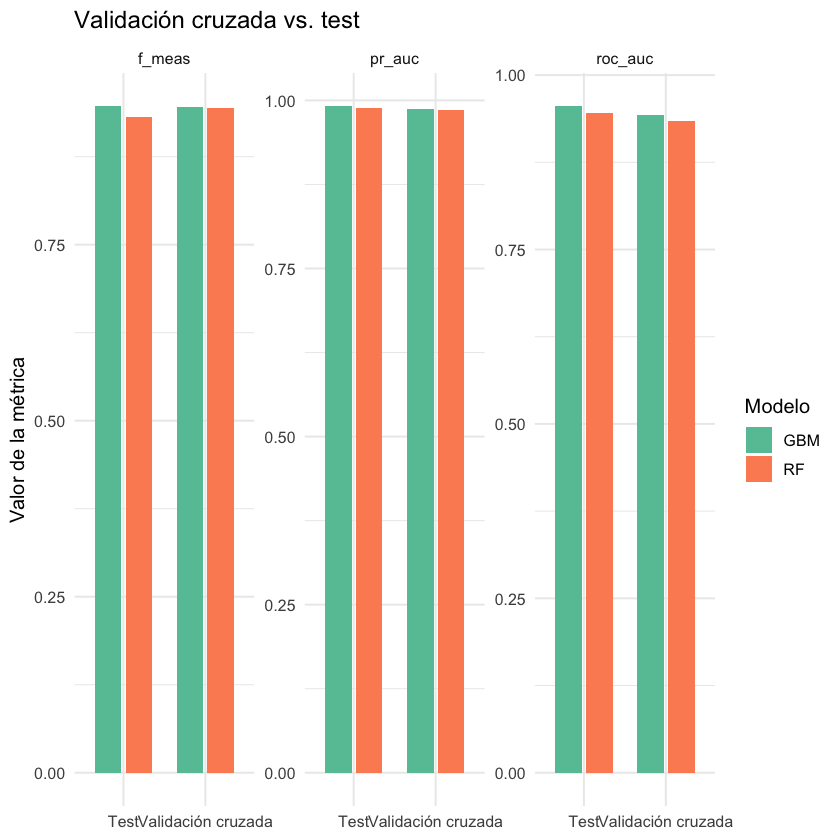

In [38]:
# Mejores resultados de validación cruzada obtenidos con tune_bayes().
comparacion_cv_clas <- metricas_bayes_clas %>%
  filter(.metric %in% c("f_meas", "roc_auc", "pr_auc")) %>%
  group_by(modelo, .metric) %>%
  slice_max(mean, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  transmute(
    modelo,
    muestra = "Validación cruzada",
    .metric,
    .estimate = mean
  )

# Resultados finales en test calculados con last_fit().
comparacion_test_clas <- metricas_test_clas %>%
  filter(.metric %in% c("f_meas", "roc_auc", "pr_auc")) %>%
  transmute(
    modelo,
    muestra = "Test",
    .metric,
    .estimate
  )

comparacion_clas <- bind_rows(comparacion_cv_clas, comparacion_test_clas)

write_csv(comparacion_clas, file.path(output_dir, "comparacion_cv_test_clasificacion.csv"))

comparacion_clas %>%
  ggplot(aes(x = muestra, y = .estimate, fill = modelo)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65) +
  facet_wrap(~ .metric, scales = "free_y") +
  scale_fill_brewer(palette = "Set2") +
  labs(
    x = NULL,
    y = "Valor de la métrica",
    fill = "Modelo",
    title = "Validación cruzada vs. test"
  )

## 6. Trabajo aplicado con datos INEC

El dataset `data_pobreza_INEC.xlsx` queda importado y preparado como `inec_modelo`. Para repetir el flujo completo en clase:

- Regresión: usar `nbi` como objetivo continuo.
- Clasificación: usar `nbi_alto` como objetivo binario.
- Excluir `canton` como predictor directo.
- Aplicar la misma lógica: `initial_split()`, `vfold_cv()`, `recipe()`, `workflow()`, `tune_grid()`, `tune_bayes()` y `last_fit()`.

Para adaptar el workflow de clasificación a regresión, deberían cambiar: la fórmula del `recipe()`, el `set_mode("regression")`, las métricas (`rmse`, `mae`) y el criterio de selección del mejor modelo. Ya no se usan probabilidades de clase ni métricas como F1, ROC AUC o PR AUC.

In [39]:
system("conda run -n rbase jupyter nbconvert --to html modulo2.ipynb")
